# 03 — Context preservation, on vs off (RQ3)

**Headline (behaviour):** measures taken in the window *after* each intervention, aligned to the intervention rather than averaged over the session: the reading-resume time and the post-intervention regression rate, with vs without preservation.

**Mechanism (and its limitation):** within the *with* runs the reader records, per intervention, the displacement the reflow induced (`viewportDeltaPx`) and the residual after the restore (`anchorErrorPx`), plus a graded outcome. All interventions in this dataset are font-size changes (layout-changing → *semantic-restart*).

N=2: descriptive, not inferential.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import _lib
_lib.apply_style()
try:
    data = _lib.read_cache()
except FileNotFoundError:
    data = _lib.load_all(); _lib.write_cache(data)


## 1 — Behaviour after each intervention, with vs without (headline)
Context preservation acts in the moments after a reflow, so each measure is aligned to an intervention's apply time rather than averaged over the session. The reading-resume time (RRT) is the time to the first forward saccade after the intervention; the regression rate is taken in the 5 s after it, against a matched 5 s baseline before it. Windows are capped at the neighbouring interventions so they never overlap.

In [2]:
pi = _lib.compute_post_intervention(data, window_s=5.0)
by = pi.groupby('condition').agg(n=('rrtMs','size'),
    rrt_median_ms=('rrtMs','median'), rrt_mean_ms=('rrtMs','mean'),
    pre_reg_rate=('preRegressionRate','mean'), post_reg_rate=('postRegressionRate','mean'),
    delta=('regressionRateDelta','mean'))
by = by.reindex([c for c in _lib.CONDITION_ORDER if c in by.index])
_lib.save_table(pi, 'post_intervention_events')
_lib.save_table(by.reset_index(), 'post_intervention_summary')
by.round(3)

,n,rrt_median_ms,rrt_mean_ms,pre_reg_rate,post_reg_rate,delta
condition,,,,,,
with,19,482.0,669.842,0.293,0.228,-0.065
without,26,650.0,922.840,0.320,0.330,0.021


### Reading-resume time (time to the next forward saccade)

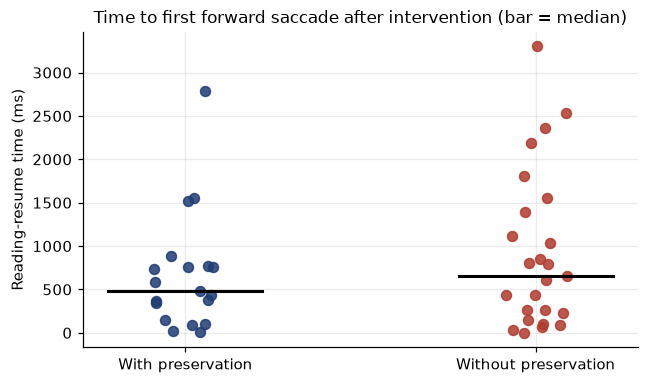

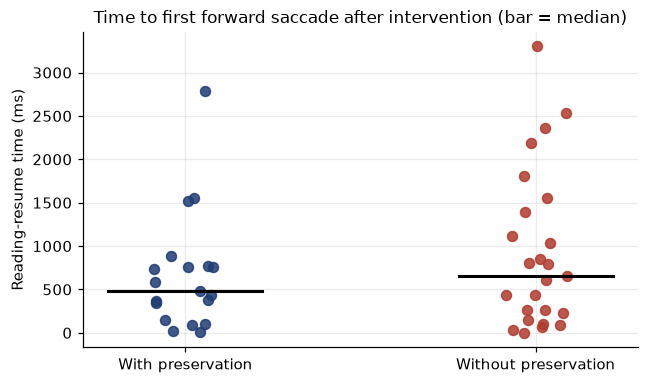

In [3]:
conds = [c for c in _lib.CONDITION_ORDER if c in pi['condition'].unique()]
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(6, 3.6))
for i, c in enumerate(conds):
    v = pi.loc[pi['condition'] == c, 'rrtMs'].dropna().values
    ax.scatter(i + (rng.random(len(v)) - 0.5)*0.18, v, s=42, alpha=0.85,
               color=_lib.CONDITION_COLORS[c], zorder=3)
    ax.plot([i-0.22, i+0.22], [np.median(v)]*2, color='black', lw=2, zorder=4)
ax.set_xticks(range(len(conds))); ax.set_xticklabels([_lib.CONDITION_LABELS[c] for c in conds])
ax.set_ylabel('Reading-resume time (ms)')
ax.set_title('Time to first forward saccade after intervention (bar = median)')
fig.tight_layout(); _lib.save_fig(fig, '03_rrt'); fig

### Regression rate before vs after the intervention
Without preservation the regression rate rises after an intervention; with it, it does not.

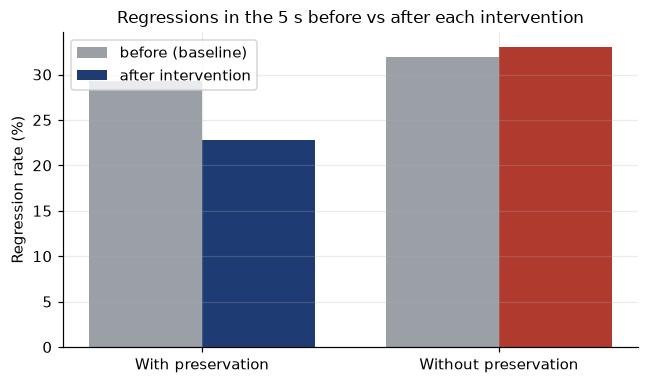

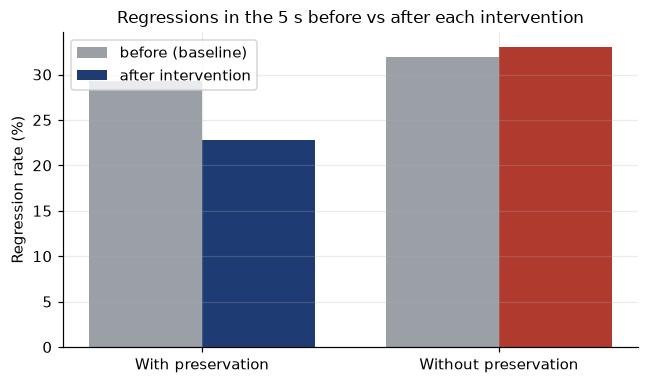

In [4]:
conds = [c for c in _lib.CONDITION_ORDER if c in by.index]
x = np.arange(len(conds)); w = 0.38
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(x - w/2, [by.loc[c, 'pre_reg_rate']*100 for c in conds], w, label='before (baseline)', color='#9aa0a6')
ax.bar(x + w/2, [by.loc[c, 'post_reg_rate']*100 for c in conds], w, label='after intervention',
       color=[_lib.CONDITION_COLORS[c] for c in conds])
ax.set_xticks(x); ax.set_xticklabels([_lib.CONDITION_LABELS[c] for c in conds])
ax.set_ylabel('Regression rate (%)'); ax.legend()
ax.set_title('Regressions in the 5 s before vs after each intervention')
fig.tight_layout(); _lib.save_fig(fig, '03_post_regression'); fig

### Sensitivity to the window length

In [5]:
rows = []
for wsec in (3.0, 5.0, 10.0):
    p = _lib.compute_post_intervention(data, window_s=wsec)
    for c in [x for x in _lib.CONDITION_ORDER if x in p['condition'].unique()]:
        sub = p[p['condition'] == c]
        rows.append({'window_s': wsec, 'condition': c,
            'post_reg_rate_pct': round(100*sub['postRegressionRate'].mean(), 1),
            'rrt_median_ms': round(float(sub['rrtMs'].median()), 0)})
sens = pd.DataFrame(rows)
_lib.save_table(sens, 'post_intervention_sensitivity')
sens

,window_s,condition,post_reg_rate_pct,rrt_median_ms
0,3.0,with,22.3,482.0
1,3.0,without,38.1,650.0
2,5.0,with,22.8,482.0
3,5.0,without,33.0,650.0
4,10.0,with,22.4,482.0
5,10.0,without,35.3,650.0


## 2 — Mechanism and its limitation
The restore runs and is fully audited, but the outcome is mostly graded *degraded*. The reason is informative rather than a recording failure: the reader's reading position drifted only a little (`viewportDeltaPx`), yet the semantic-restart strategy repositions the committed sentence to its target, so the residual (`anchorErrorPx`) *exceeds* the induced displacement. For small font-size reflows the restore is over-aggressive — a limitation we return to as future work (a gentler, Kalman-filter-style stabilisation, or keeping the reader's exact offset for small changes).

In [6]:
cp = data.context_preservation.copy()
iv = data.interventions[['sessionKey','appliedAtUnixMs','affectedProperties','restoreMode','fontSizePx']]
cp = cp.sort_values('interventionAppliedAtUnixMs')
iv = iv.sort_values('appliedAtUnixMs')
cp = pd.merge_asof(cp, iv, left_on='interventionAppliedAtUnixMs', right_on='appliedAtUnixMs',
                   by='sessionKey', direction='nearest', tolerance=2000)
outcome = cp.groupby('status').agg(n=('status','size'),
    median_anchorErrorPx=('anchorErrorPx','median'),
    median_viewportDeltaPx=('viewportDeltaPx','median')).reset_index()
_lib.save_table(cp, 'context_preservation_events')
_lib.save_table(outcome, 'context_preservation_outcomes')
outcome.round(2)

,status,n,median_anchorErrorPx,median_viewportDeltaPx
0,degraded,16,389.0,38.66
1,preserved,3,0.0,34.00


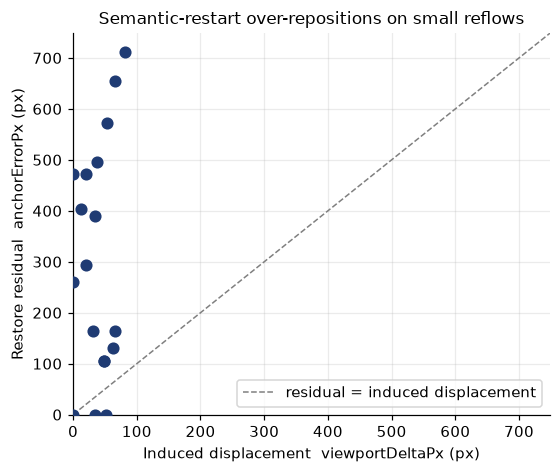

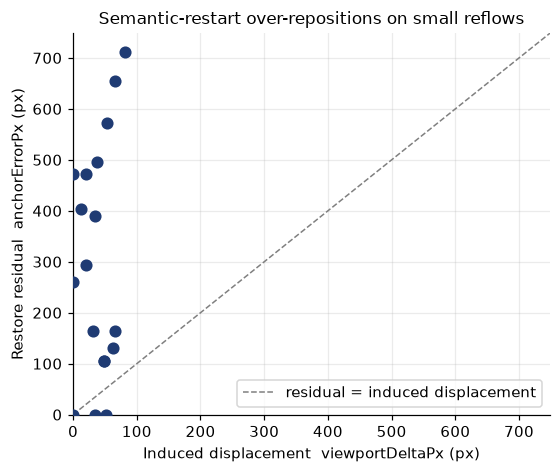

In [7]:
# Honest limitation figure: restore residual vs the displacement actually induced.
# Points above the dashed line mean the restore moved the reader MORE than the reflow did.
ev = cp.reset_index(drop=True).copy()
m = ev['anchorErrorPx'].notna() & ev['viewportDeltaPx'].notna()
ev = ev[m]
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(ev['viewportDeltaPx'], ev['anchorErrorPx'], s=48, zorder=3,
           color=_lib.CONDITION_COLORS['with'])
lim = float(max(ev['viewportDeltaPx'].max(), ev['anchorErrorPx'].max())) * 1.05 + 1
ax.plot([0, lim], [0, lim], ls='--', c='gray', lw=1, label='residual = induced displacement')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('Induced displacement  viewportDeltaPx (px)')
ax.set_ylabel('Restore residual  anchorErrorPx (px)')
ax.set_title('Semantic-restart over-repositions on small reflows')
ax.legend(loc='lower right')
fig.tight_layout(); _lib.save_fig(fig, '03_restore_overreposition'); fig